# Predictive Models and Prioritisation

Builds, evaluates, and interprets the two arrears risk models — logistic regression
and XGBoost — then applies the equity overlay to produce a ranked priority list.

This notebook uses the package's model builders (`make_lr_pipeline`,
`make_xgb_pipeline`) and evaluators (`cross_validate_model`,
`evaluate_held_out`). Running `arrears-train` from the command line does the
same thing and also persists the fitted pipelines and metadata to `models/`.

Sections:
1. Predictive models — CV, held-out evaluation, ROC/PR curves, SHAP, geographic risk
2. Prioritisation — equity overlay, ranked priority list


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import shap
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, precision_recall_curve, auc

from arrears_risk_model.config import load_config
from arrears_risk_model.data import prepare_dataset
from arrears_risk_model.evaluate import (
    compute_calibration,
    evaluate_held_out,
    tune_and_cross_validate,
)
from arrears_risk_model.models import make_lr_pipeline, make_xgb_pipeline
from arrears_risk_model.predict import _CHILDREN_HOUSEHOLD_TYPES, apply_equity_overlay
from arrears_risk_model.logging_config import configure_logging

configure_logging()
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
PLOT_DIR = Path("../results/plots")
PLOT_DIR.mkdir(parents=True, exist_ok=True)


## 1. Predictive Models

### 1.1 Load data and train/test split


In [2]:
config = load_config()
paths = config.paths.resolved()

dataset = prepare_dataset(paths.household_data, paths.imd_data)
print(f"Dataset: {dataset.shape[0]:,} rows x {dataset.shape[1]} columns")

target = config.features.target
x_df = dataset.drop(columns=[target])
y = dataset[target]

x_train, x_test, y_train, y_test = train_test_split(
    x_df, y,
    test_size=config.training.test_size,
    random_state=config.training.random_state,
    stratify=y,
)
print(f"\nTrain: {len(x_train):,}  Test: {len(x_test):,}")
print(f"Positive rate  train={y_train.mean():.1%}  test={y_test.mean():.1%}")


2026-05-05T11:11:59 | INFO     | arrears_risk_model.data | Reading household data from /media/nadinespy/NewVolume1/work/packages_and_code_repos/arrears-risk-model/data/household_data.xlsx


2026-05-05T11:12:05 | INFO     | arrears_risk_model.data | Loaded 17831 rows, 21 columns
2026-05-05T11:12:05 | INFO     | arrears_risk_model.data | Null counts: {'ben_cap_amount': 1}
2026-05-05T11:12:05 | INFO     | arrears_risk_model.data | Reading IMD data from /media/nadinespy/NewVolume1/work/packages_and_code_repos/arrears-risk-model/data/File_1_IoD2025_Index_of_Multiple_Deprivation.xlsx (sheet=IMD25)
2026-05-05T11:12:10 | INFO     | arrears_risk_model.data | Loaded 33755 LSOAs
2026-05-05T11:12:10 | INFO     | arrears_risk_model.data | Arrears flag/amount consistency check: all 17831 rows OK
2026-05-05T11:12:10 | INFO     | arrears_risk_model.data | IMD join: 17831 rows, all LSOAs matched


Dataset: 17,831 rows x 23 columns

Train: 14,264  Test: 3,567
Positive rate  train=25.5%  test=25.5%


### 1.2 Logistic regression — hyperparameter tuning + cross-validation


In [3]:
lr_pipeline = make_lr_pipeline(config)
lr_grid = config.hyperparameter_search.lr_grid

print(f"Tuning LR via GridSearchCV (grid: {lr_grid})...")
lr_pipeline, lr_cv = tune_and_cross_validate(
    lr_pipeline, x_train, y_train, lr_grid, config, "lr",
)
print(f"  best params: {lr_cv.best_params}")
print(f"  ROC-AUC  {lr_cv.roc_auc_mean:.3f} +/- {lr_cv.roc_auc_std:.3f}")
print(f"  PR-AUC   {lr_cv.pr_auc_mean:.3f} +/- {lr_cv.pr_auc_std:.3f}")
print(f"  F1       {lr_cv.f1_mean:.3f} +/- {lr_cv.f1_std:.3f}")


Tuning LR via GridSearchCV (grid: {'C': [0.1, 1.0, 10.0]})...


2026-05-05T11:12:32 | INFO     | arrears_risk_model.evaluate | lr tuned: best_params={'C': 0.1} | ROC-AUC 0.767 ± 0.017 | PR-AUC 0.498 ± 0.033 | F1 0.545 ± 0.017


  best params: {'C': 0.1}
  ROC-AUC  0.767 +/- 0.017
  PR-AUC   0.498 +/- 0.033
  F1       0.545 +/- 0.017


### 1.3 XGBoost — hyperparameter tuning + cross-validation


In [4]:
xgb_pipeline = make_xgb_pipeline(config)
xgb_grid = config.hyperparameter_search.xgb_grid

print(f"Tuning XGB via GridSearchCV (grid: {xgb_grid})...")
xgb_pipeline, xgb_cv = tune_and_cross_validate(
    xgb_pipeline, x_train, y_train, xgb_grid, config, "xgb",
)
print(f"  best params: {xgb_cv.best_params}")
print(f"  ROC-AUC  {xgb_cv.roc_auc_mean:.3f} +/- {xgb_cv.roc_auc_std:.3f}")
print(f"  PR-AUC   {xgb_cv.pr_auc_mean:.3f} +/- {xgb_cv.pr_auc_std:.3f}")
print(f"  F1       {xgb_cv.f1_mean:.3f} +/- {xgb_cv.f1_std:.3f}")


Tuning XGB via GridSearchCV (grid: {'n_estimators': [100, 200], 'max_depth': [3, 6], 'learning_rate': [0.05, 0.1]})...


2026-05-05T11:13:12 | INFO     | arrears_risk_model.evaluate | xgb tuned: best_params={'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100} | ROC-AUC 0.780 ± 0.015 | PR-AUC 0.529 ± 0.022 | F1 0.555 ± 0.016


  best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
  ROC-AUC  0.780 +/- 0.015
  PR-AUC   0.529 +/- 0.022
  F1       0.555 +/- 0.016


### 1.4 Held-out evaluation

In [5]:
# Pipelines are already refit on the full training set by GridSearchCV.
lr_held = evaluate_held_out(lr_pipeline, x_test, y_test, "lr")
lr_cal  = compute_calibration(lr_pipeline, x_test, y_test, "lr")
xgb_held = evaluate_held_out(xgb_pipeline, x_test, y_test, "xgb")
xgb_cal  = compute_calibration(xgb_pipeline, x_test, y_test, "xgb")

print("\n--- Held-out test set ---")
print(f"{'Model':<8} {'ROC-AUC':>8} {'PR-AUC':>8} {'F1':>8} {'Brier':>8}")
for name, res, cal in [("LR", lr_held, lr_cal), ("XGB", xgb_held, xgb_cal)]:
    print(f"{name:<8} {res.roc_auc:>8.3f} {res.pr_auc:>8.3f} {res.f1:>8.3f} {cal.brier_score:>8.3f}")


2026-05-05T11:13:12 | INFO     | arrears_risk_model.evaluate | lr held-out: ROC-AUC 0.773 | PR-AUC 0.514 | F1 0.546 | precision 0.425 | recall 0.763
2026-05-05T11:13:12 | INFO     | arrears_risk_model.evaluate | lr Brier score: 0.1955


2026-05-05T11:13:12 | INFO     | arrears_risk_model.evaluate | xgb held-out: ROC-AUC 0.788 | PR-AUC 0.541 | F1 0.559 | precision 0.436 | recall 0.779
2026-05-05T11:13:12 | INFO     | arrears_risk_model.evaluate | xgb Brier score: 0.1887



--- Held-out test set ---
Model     ROC-AUC   PR-AUC       F1    Brier
LR          0.773    0.514    0.546    0.196
XGB         0.788    0.541    0.559    0.189


### 1.5 ROC and precision-recall curves

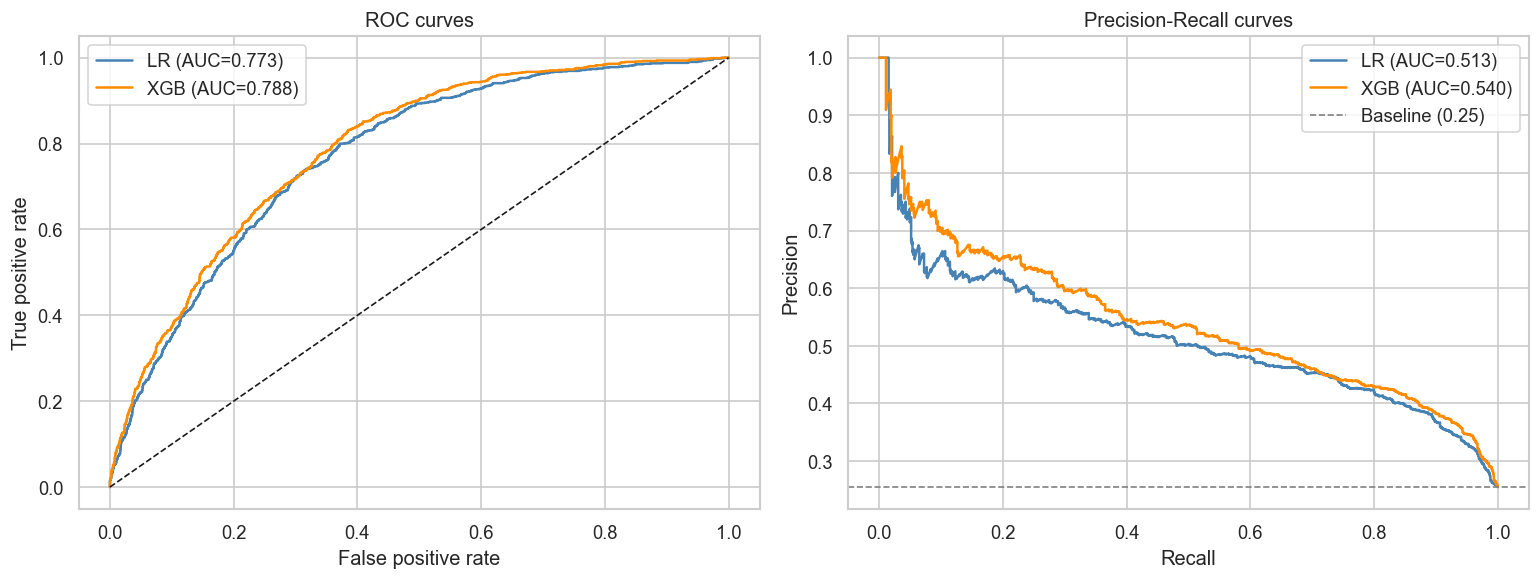

In [6]:
lr_proba = lr_pipeline.predict_proba(x_test)[:, 1]
xgb_proba = xgb_pipeline.predict_proba(x_test)[:, 1]

fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(13, 5))

for name, proba, color in [
    ("LR", lr_proba, "steelblue"),
    ("XGB", xgb_proba, "darkorange"),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax_roc.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr, tpr):.3f})", color=color)

    prec, rec, _ = precision_recall_curve(y_test, proba)
    ax_pr.plot(rec, prec, label=f"{name} (AUC={auc(rec, prec):.3f})", color=color)

ax_roc.plot([0, 1], [0, 1], "k--", lw=1)
ax_roc.set_xlabel("False positive rate")
ax_roc.set_ylabel("True positive rate")
ax_roc.set_title("ROC curves")
ax_roc.legend()

baseline = y_test.mean()
ax_pr.axhline(baseline, color="grey", lw=1, linestyle="--", label=f"Baseline ({baseline:.2f})")
ax_pr.set_xlabel("Recall")
ax_pr.set_ylabel("Precision")
ax_pr.set_title("Precision-Recall curves")
ax_pr.legend()

plt.tight_layout()
plt.savefig(PLOT_DIR / "05_roc_pr_curves.png", bbox_inches="tight")
plt.show()

### 1.6 Feature importance — SHAP values (XGB)

SHAP values are computed on the transformed test set (after the preprocessor step)
so they reflect the features actually seen by the XGBoost classifier.


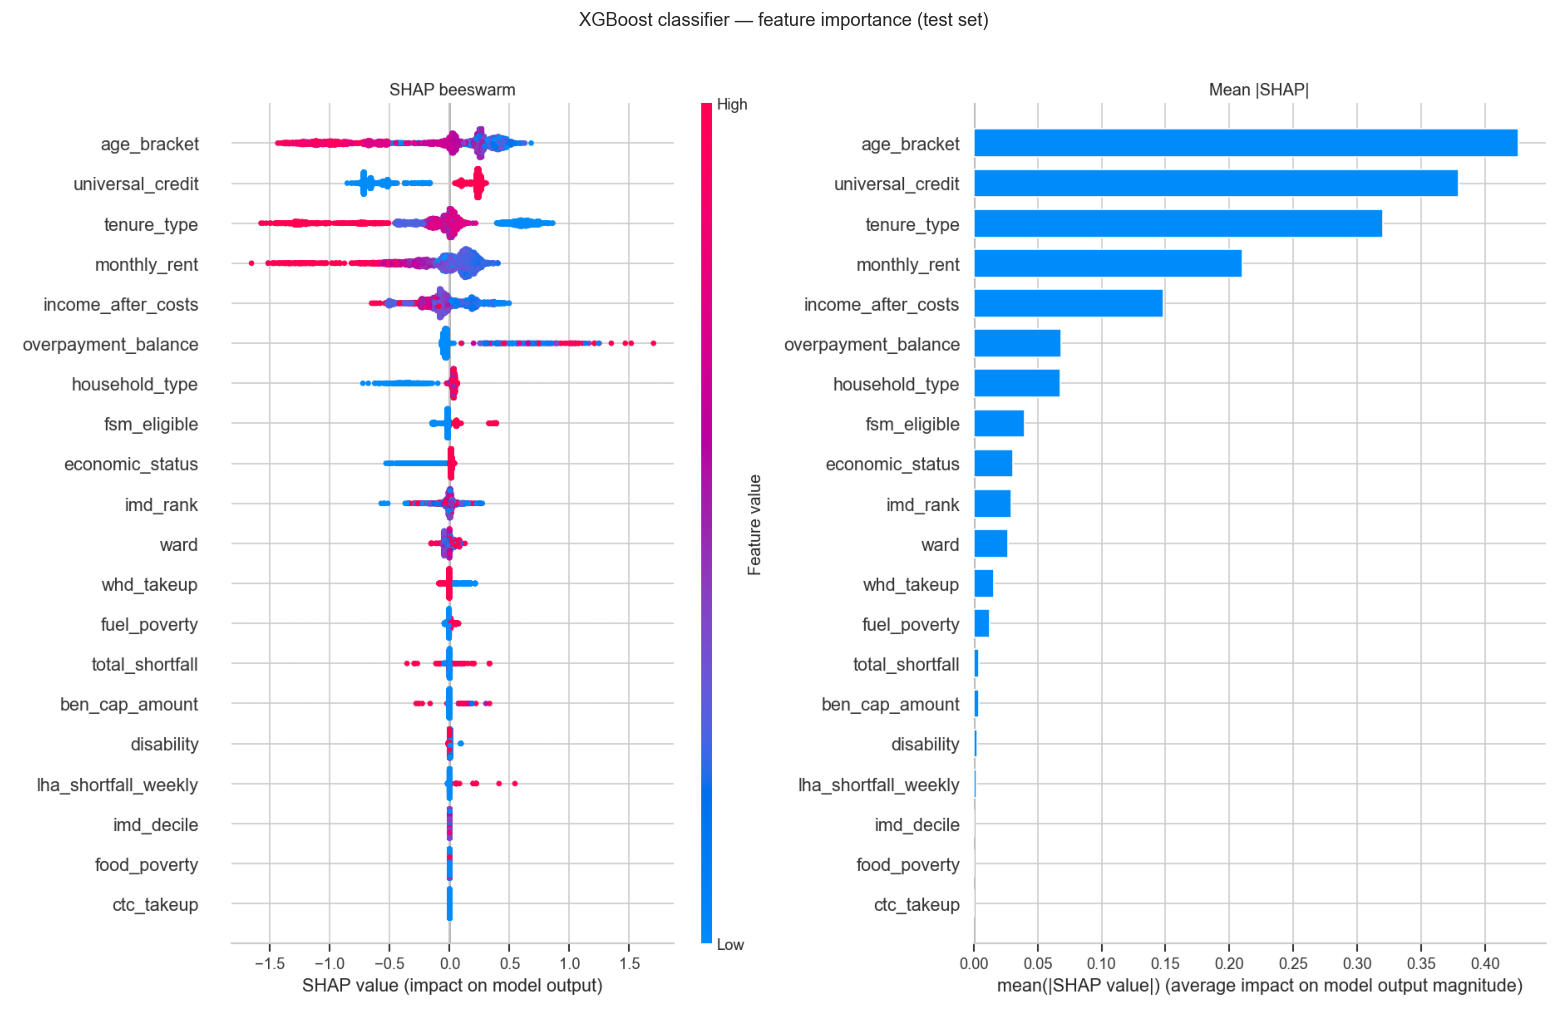

In [7]:
# Pull the fitted classifier and the ColumnTransformer out of the nested pipeline.
# Structure: xgb_pipeline = Pipeline([("preprocessor", Pipeline([("engineer", FT), ("column_transform", CT)])), ("clf", XGBClassifier)]).
xgb_fitted    = xgb_pipeline.named_steps["clf"]
preprocessor  = xgb_pipeline.named_steps["preprocessor"]
ct            = preprocessor.named_steps["column_transform"]

# TreeExplainer needs raw, preprocessed features matching the booster.
x_test_transformed = preprocessor.transform(x_test)

# Strip transformer-name prefixes ("continuous__monthly_rent" -> "monthly_rent").
feature_names = [n.split("__", 1)[-1] for n in ct.get_feature_names_out()]

explainer = shap.TreeExplainer(xgb_fitted)
shap_values = explainer.shap_values(x_test_transformed)

# Render beeswarm and bar plots to image buffers, then composite side-by-side
from io import BytesIO
from PIL import Image

buffers = []
for plot_type, title in [("dot", "SHAP beeswarm"), ("bar", "Mean |SHAP|")]:
    plt.figure(figsize=(7, 6))
    shap.summary_plot(shap_values, x_test_transformed,
                      feature_names=feature_names,
                      plot_type=plot_type, show=False, max_display=20)
    plt.title(title)
    plt.tight_layout()
    buf = BytesIO()
    plt.gcf().savefig(buf, format="png", dpi=120, bbox_inches="tight")
    plt.close("all")
    buf.seek(0)
    buffers.append(Image.open(buf))

total_w = sum(img.width for img in buffers)
max_h   = max(img.height for img in buffers)
composite = Image.new("RGB", (total_w, max_h), "white")
composite.paste(buffers[0], (0, 0))
composite.paste(buffers[1], (buffers[0].width, 0))

aspect = max_h / total_w
fig, ax = plt.subplots(figsize=(14, 14 * aspect))
ax.imshow(composite)
ax.axis("off")
fig.suptitle("XGBoost classifier — feature importance (test set)", fontsize=11, y=1.0)
plt.tight_layout()
plt.savefig(PLOT_DIR / "05_shap_importance.png", dpi=150, bbox_inches="tight")
plt.show()


### 1.7 Geographic aggregation — LSOA-level predicted risk

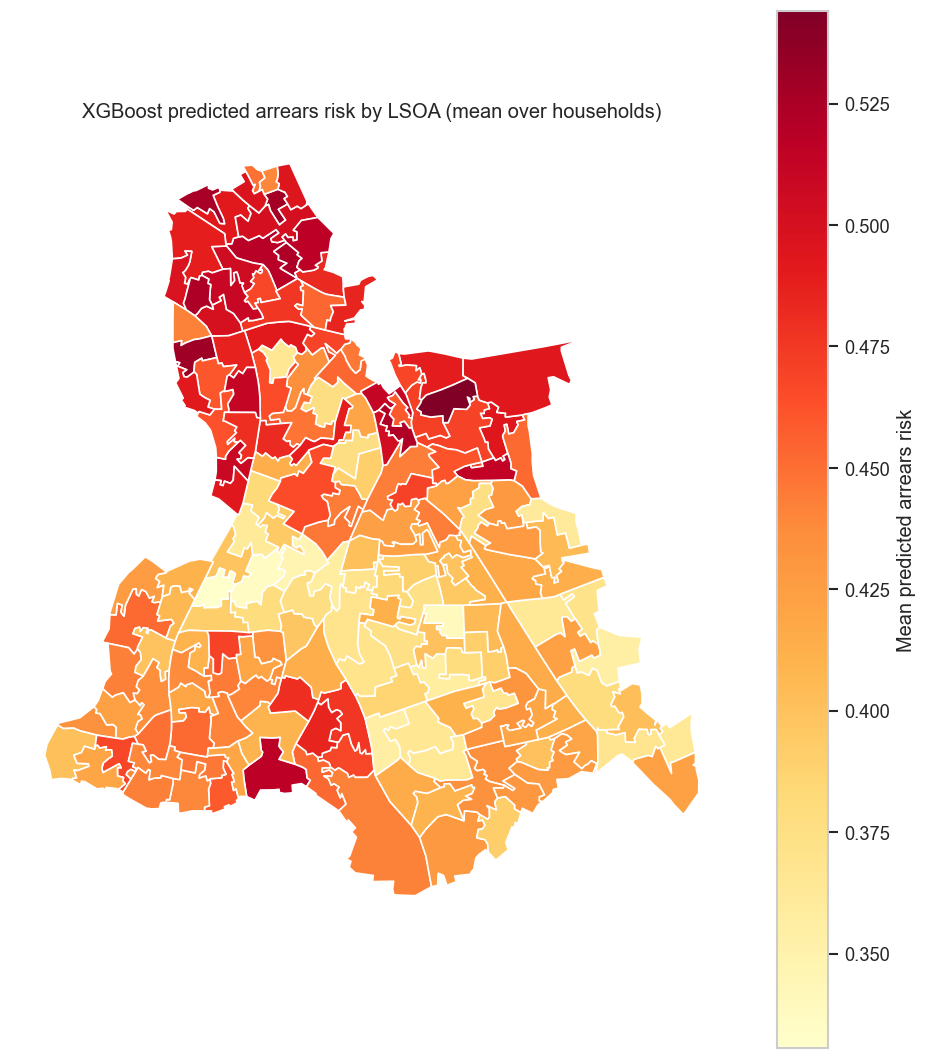

In [8]:
# Score all households and aggregate to LSOA level
all_proba = xgb_pipeline.predict_proba(x_df)[:, 1]

lsoa_risk = (
    dataset[["lsoa21cd"]]
    .assign(predicted_proba=all_proba)
    .groupby("lsoa21cd")["predicted_proba"]
    .mean()
    .reset_index()
    .rename(columns={"predicted_proba": "mean_predicted_risk"})
)

geo = gpd.read_file(paths.lewisham_geojson)
lsoa_code_col = next(
    (c for c in geo.columns if "LSOA" in c.upper() and "CD" in c.upper()), None
)
geo_merged = geo.merge(lsoa_risk, left_on=lsoa_code_col, right_on="lsoa21cd", how="left")

fig, ax = plt.subplots(figsize=(8, 9))
geo_merged.plot(
    column="mean_predicted_risk", ax=ax, cmap="YlOrRd", legend=True,
    legend_kwds={"label": "Mean predicted arrears risk"},
    missing_kwds={"color": "lightgrey"},
)
ax.set_title("XGBoost predicted arrears risk by LSOA (mean over households)")
ax.axis("off")
plt.tight_layout()
plt.savefig(PLOT_DIR / "05_geographic_risk.png", bbox_inches="tight")
plt.show()

### 1.8 Key takeaways

- Both models achieve ROC-AUC in the 0.77–0.79 range; XGB slightly outperforms LR on held-out data.
- PR-AUC is substantially lower (~0.50–0.55) — expected with ~25% positive rate; precision–recall trade-off should be reviewed at the operating threshold rather than fixed at 0.5.
- Brier scores are comparable; the equity overlay assumption of reasonable calibration holds.
- SHAP analysis identifies `income_after_costs`, `lha_shortfall_weekly`, and `overpayment_balance` as the strongest predictors.
- Ward-level geographic signal (`imd_rank`, `imd_decile`) contributes modestly but consistently.
- High-risk LSOAs cluster in north-east Lewisham in the geographic map — consistent with the IMD analysis in notebook 01.


## 2. Prioritisation

### 2.1 Approach

Apply the XGBoost classifier to all households not currently in arrears. Each receives a
predicted probability (0–1) serving as a continuous risk score. Rank by this score and
select the top 10% (~1,340 of ~13,280 non-arrears households) as the candidate
intervention list.

### 2.2 Model precision

The model is a screening tool, not a precise decision system. PR-AUC ~0.52 and F1 ~0.53
mean the ranking is better than random, but the top 10% will include false positives and
miss some true positives. Human caseworker review is required before any contact or
resource allocation decision.

### 2.3 Equity considerations

Prioritisation need not be determined by the model alone. Explicit equity criteria can be
layered on top:

- **Presence of children**: proxied by `household_type` ∈ {Lone parent, Couple with children}
  and `fsm_eligible = 1`
- **Disability**: `disability = 1`

These reflect value judgements about who deserves support, not statistical associations.

### 2.4 Composite priority score

```
priority = predicted_probability + equity_weights
```

Equity weights are explicitly defined — `+config.equity.children` for households with
children, `+config.equity.disability` for disabled members. The weights are auditable and
configurable in `config/default.yaml` without code changes.

`apply_equity_overlay()` in `arrears_risk_model.predict` implements this. The full
production output (ranked CSV with `composite_score` and `rank` columns) is generated by
`arrears-predict`.

### 2.5 Severity as a future extension

The prioritisation above is based on risk alone. A severity model predicting `arrears_amount`
could add a second dimension: who is at risk of accumulating large debts that become harder
to recover from. This would be relevant if the policy goal shifts from *preventing arrears*
to *preventing high arrears*. Severity modelling is deferred to future work.
